# Creating a programming assistant using Prompt Chaining workflows

## Create the environment 

In [1]:

# Creare environment
import os 
from dotenv import load_dotenv 
load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY") 
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")


# Get LLM model 
from langchain.chat_models import init_chat_model 

primary_llm = init_chat_model(model="llama-3.3-70b-versatile", model_provider="Groq")

fallback_llm_1 = init_chat_model(model="gpt-5.4-nano", model_provider="openai",
                 model_kwargs={"temperature": 0.5, "max_tokens": 1000})
fallback_llm_2 = init_chat_model(model="gpt-5.4-mini", model_provider="openai",
                 model_kwargs={"temperature": 0.5, "max_tokens": 1000})


from langgraph.graph import StateGraph, MessagesState, START, END

/Users/nali/Documents/YTLLMs/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/nali/Documents/YTLLMs/.venv/lib/python3.13/site-packages/langchain/chat_models/base.py:494: UserWarning: Parameters {'max_tokens', 'temperature'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  return _init_chat_model_helper(


## Create a ProgrammingAssistant state class 

In [3]:
from typing_extensions import TypedDict

class ProgrammingState(TypedDict):
    user_requests: str
    programming_language: str

    code_generation:str
    code_explanation:str
    complexity_analysis:str
    report_generation:str   

## create code_generation state

In [5]:
def code_generation(state:ProgrammingState)->ProgrammingState:
    """Generate code based on youser requests"""
    prompt = f"""
    You are an expert coder in {state["programming_language"]}. 
    Please generate the code based on the rewuests of {state["user_requests"]}
   
    Requirements: 
    - Just generate the code
    """

    response = primary_llm.invoke(prompt)

    return {"code_generation":response.content} 


## Create code_explanation state

In [14]:
def code_explanation(state:ProgrammingState)->ProgrammingState:
    """Explain the generated code"""
    prompt = f"""
    You are an expert instruction in Computer Science. 
    Explain the code with some examples. 

    {state["code_generation"]}

    based on user requests: 

    {state["user_requests"]}

   
    Requirements: 
    - Explain the code for a successful search 
    - Also for an unsuccessful search 
    """

    response = primary_llm.invoke(prompt)

    return {"code_explanation":response.content} 

## Create Cmmplexity analysis state 

In [16]:
def complexity_analysis(state:ProgrammingState)->ProgrammingState:
    """Analyse the complexity"""
    prompt = f"""
    You are an expert instruction in Computer Science. 
    Analyse the complexity of the 

    {state["code_generation"]}

    based on user requests: 

    {state["user_requests"]}

   
    Requirements: 
    - Use Big-notation
    - Find best-case, average-case, and worst-case complexity
    """

    response = primary_llm.invoke(prompt)

    return {"complexity_analysis":response.content} 

## Generate the final report 

In [26]:
def report_generation(state:ProgrammingState)->ProgrammingState:

    final_report = f"""
    
    Programming Assistant Report
    =============================

    User requests:
    -----------------

    {state["user_requests"]}

    Programming language: 
    -----------------------

    {state["programming_language"]}

    Generated code:
    ------------------

    {state["code_generation"]}

    Code explanation:
    -------------------

    {state["code_explanation"]}

    Complexity Analysis:
    ----------------------

    {state["complexity_analysis"]}

    """

    return {"report_generation":final_report}

## Build the graph 

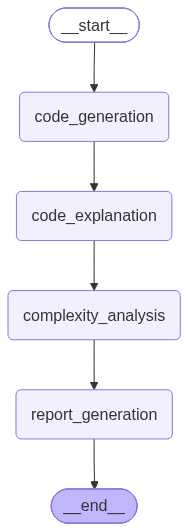

In [27]:
graph = StateGraph(ProgrammingState)

graph.add_node(code_generation)
graph.add_node(code_explanation)
graph.add_node(complexity_analysis)
graph.add_node(report_generation)

## connect edges 

graph.add_edge(START, "code_generation")
graph.add_edge("code_generation", "code_explanation")
graph.add_edge("code_explanation","complexity_analysis")
graph.add_edge("complexity_analysis","report_generation")
graph.add_edge("report_generation",END)

graph = graph.compile()
graph



## Invoke for testing 

In [30]:
initial_state = {
    "user_requests":"""
    Create a binary search. Use a sorted array and a target element.
    Return the found index position for a successful search. 
    Otherwise return -1. 
    """, 
    "programming_language":"python"
}

In [31]:
response = graph.invoke(initial_state)
print(response["report_generation"])



    Programming Assistant Report

    User requests:
    -----------------

    
    Create a binary search. Use a sorted array and a target element.
    Return the found index position for a successful search. 
    Otherwise return -1. 
    

    Programming language: 
    -----------------------

    python

    Generated code:
    ------------------

    ```python
def binary_search(arr, target):
    """
    Performs a binary search on a sorted array.

    Args:
        arr (list): A sorted list of elements.
        target: The target element to be searched.

    Returns:
        int: The index of the target element if found, -1 otherwise.
    """
    low = 0
    high = len(arr) - 1

    while low <= high:
        mid = (low + high) // 2
        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1

    return -1


# Example usage
arr = [2, 5, 8, 12, 16, 23, 38, 56, 72, 91]
target = 23
result